# Интеллектуальные методы обработки видео

# Ноутбук разделен на два задания:
   * ### [Эвристический SCD](#first)
   * ### [SCD с ML](#second)
   
Сроки выполнения для каждого задания — одна неделя. Оцениваются задания независимо.

## Задание 1. Scene Change Detector
<a id='first'></a>

### Обязательно к прочтению

**Внимание!**

Opencv содержит очень много высокоуровневых функций обработки изображений (например, некоторые алгоритмы компенсации движения, отслеживания объектов, распознавания образов). Использование данной библиотеки в данном задании ограничивается:
* считыванием входного видео
* преобразованием его кадров в другие цветовые пространства
* использованием свёрток Собеля

Использовать библиотеку numpy можно без ограничений.

Если вы хотите использовать функции обработки изображений и видео из другой библиотеки, то оговорите использование этой функции в чате курса.

### Описание входных данных

Выборка для тренировки лежит https://titan.gml-team.ru:5003/sharing/yX8enupJV

Данные о каждом видео лежат в файле *train_dataset\info.json*. Это список из словарей, каждый словарь содержит информацию о расположении видео, о расположении ответов на смены сцен и содержит длину видео

In [1]:
import numpy as np
import cv2 # Для установки opencv воспользуйтесь командой в терминале conda install -c conda-forge opencv
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

/Users/bigmilk/Desktop/vatolin/video/venv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json
def load_json_from_file(filename):
    with open(filename, "r") as f:
        return json.load(f, strict=False)


def dump_json_to_file(obj, filename, **kwargs):
    with open(filename, "w") as f:
        json.dump(obj, f, **kwargs)

In [3]:
video_dataset = load_json_from_file('train_dataset/info.json')
video_dataset

[{'source': 'video/03.mp4', 'scene_change': 'gt/03.json', 'len': 3250},
 {'source': 'video/04.mp4', 'scene_change': 'gt/04.json', 'len': 3392},
 {'source': 'video/05.mp4', 'scene_change': 'gt/05.json', 'len': 5662},
 {'source': 'video/07.mp4', 'scene_change': 'gt/07.json', 'len': 3321},
 {'source': 'video/08.mp4', 'scene_change': 'gt/08.json', 'len': 3396},
 {'source': 'video/10.mp4', 'scene_change': 'gt/10.json', 'len': 6096},
 {'source': 'video/14.mp4', 'scene_change': 'gt/14.json', 'len': 2326},
 {'source': 'video/17.mp4', 'scene_change': 'gt/17.json', 'len': 2905},
 {'source': 'video/21.mp4', 'scene_change': 'gt/21.json', 'len': 4898},
 {'source': 'video/22.mp4', 'scene_change': 'gt/22.json', 'len': 7749}]

### Загрузка видео ###

Загрузка видео осуществляется при помощи cv2.VideoCapture. Этот код изменять и дописывать не нужно.

In [4]:
def read_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while(cap.isOpened()):
        ret, frame = cap.read()
        if ret==False:
            break
        yield frame
    cap.release()

In [5]:
frames = read_video(os.path.join('train_dataset', 'video', '03.mp4'))

Что такое frames? Это итератор на кадры видео. Чтобы пройтись по всем кадрам последовательности, воспользуйтесь следующей конструкцией:
*Аккуратно, по одной переменной frames можно пройти только один раз!*

In [6]:
for frame in tqdm(frames):
    pass
for frame in tqdm(frames): # Второй раз уже не будет итерации
    pass

3250it [00:02, 1379.85it/s]
0it [00:00, ?it/s]


### Пишем свой простой детектор смен сцен

На данном этапе предлагается написать простой Scene Change Detector (SCD) на основе выделения характеристик кадров, подсчёта разницы между кадрами на основе данных характеристик, а также подобрать наиболее оптимальный порог для этих признаков и совместить эти признаки.
Сменой сцен в данной задаче являются только обычные мгновенные смены сцен, без дополнительных эффектов.

В качестве примера приведён простой детектор смен, который считает межкадровую разницу между кадрами.

*Важное замечание. Здесь и далее результатом алгоритма детектора сцен являются **индексы кадров начал сцен**, при этом кадры **нумеруются с 0**. Нулевой кадр в качестве ответа указывать не нужно*

<img src="Hard_cut.jpg">

In [7]:
def baseline_scene_change_detector(frames, threshold=2000, with_vis=False):
    """
    Baseline SCD

    Arguments:
    frames -- iterator on video frames
    threshold -- parameter of your algorithm (optional)
    with_vis -- saving neighboring frames at a scene change (optional)

    Returns:
    scene_changes -- list of scene changes (idx of frames)
    vis -- list of neighboring frames at a scene change (for visualization)
    metric_values -- list of metric values (for visualization)
    """
    
    def pixel_metric(frame, prev_frame):
        # Базовое расстояние между кадрами - среднеквадратическая ошибка между ними
        return np.mean((frame.astype(np.int32) - prev_frame) ** 2)

    scene_changes = []
    vis = []
    metric_values = []
    prev_frame = None
    for idx, frame in tqdm(enumerate(frames), leave=False):
        # frame - это кадр
        # idx - это номер кадра
        if prev_frame is not None:
            # Находим расстояние между соседними кадрами
            metric_value = pixel_metric(frame, prev_frame)
            if metric_value > threshold:
                scene_changes.append(idx)
                if with_vis:
                    # Кадры в памяти занимают много места, поэтому сохраним лишь первые 100 срабатываний
                    if len(vis) < 100:
                        vis.append([prev_frame, frame])
            metric_values.append(metric_value)
        else:
            metric_values.append(0)
        prev_frame = frame
    return scene_changes, vis, metric_values

In [8]:
frames = read_video(os.path.join('train_dataset', 'video', '03.mp4'))
cuts_base = load_json_from_file(os.path.join('train_dataset', 'gt', '03.json'))['cut']
scene_changes_base, vis_base, metric_values_base = baseline_scene_change_detector(frames, with_vis=True)

Посмотрим визуально, насколько сильно алгоритм ошибается, а также на значения метрики

In [9]:
def visualize_metric_error(frame, prev_frame, value):
    fig = plt.figure(figsize=(16,4))
    plt.suptitle('Значение метрики на текущем кадре: {:.4f}'.format(value), fontsize=24)
    ax = fig.add_subplot(1, 2, 1)
    ax.imshow(prev_frame[:,:,::-1])
    ax.set_title("Предыдущий кадр", fontsize=18)
    ax.set_xticks([])
    ax.set_yticks([])
    ax = fig.add_subplot(1, 2, 2)
    ax.imshow(frame[:,:,::-1])
    ax.set_title("Текущий кадр", fontsize=18)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.subplots_adjust(top=0.80)

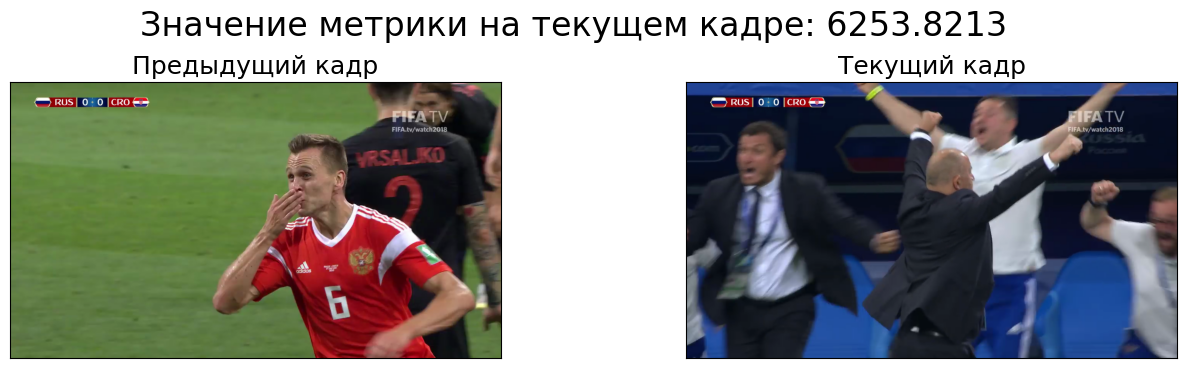

In [10]:
idx = 1
visualize_metric_error(vis_base[idx][0], vis_base[idx][1], metric_values_base[scene_changes_base[idx]])
# смена сцен

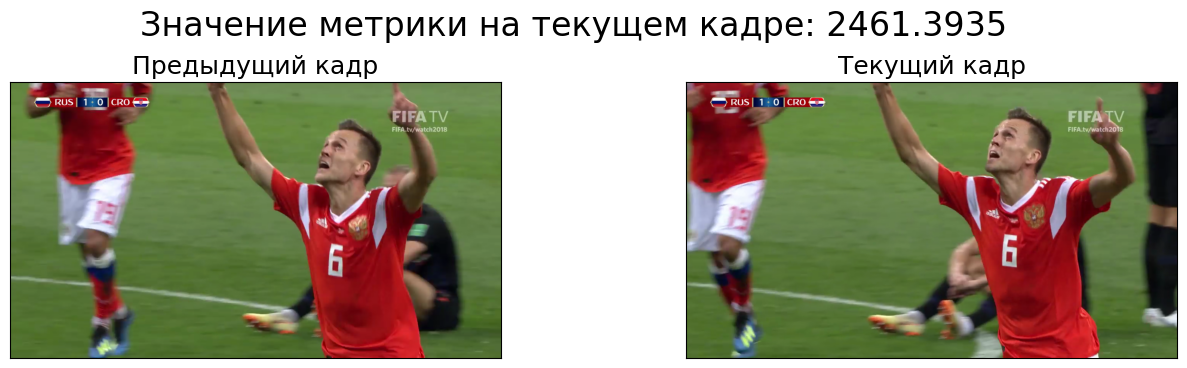

In [11]:
idx = 10
visualize_metric_error(vis_base[idx][0], vis_base[idx][1], metric_values_base[scene_changes_base[idx]])
# ошибается, это не смена сцен

In [12]:
def visualize_metric_values(metric_values, threshold, cuts = None):
    sns.set()
    plt.figure(figsize=(16, 8))
    plt.plot(metric_values, label='Значение метрики на кадрах')
    plt.xlabel('Номер кадра')
    plt.ylabel('Значение метрики')
    plt.hlines(y=threshold, xmin=0, xmax=len(metric_values), linewidth=2, color='r', label='Пороговое значение')
    
    if cuts is not None:
        for cut in cuts:
            plt.axvline(x=cut, color='k', linestyle=':', linewidth=0.5, label='Смена сцены')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

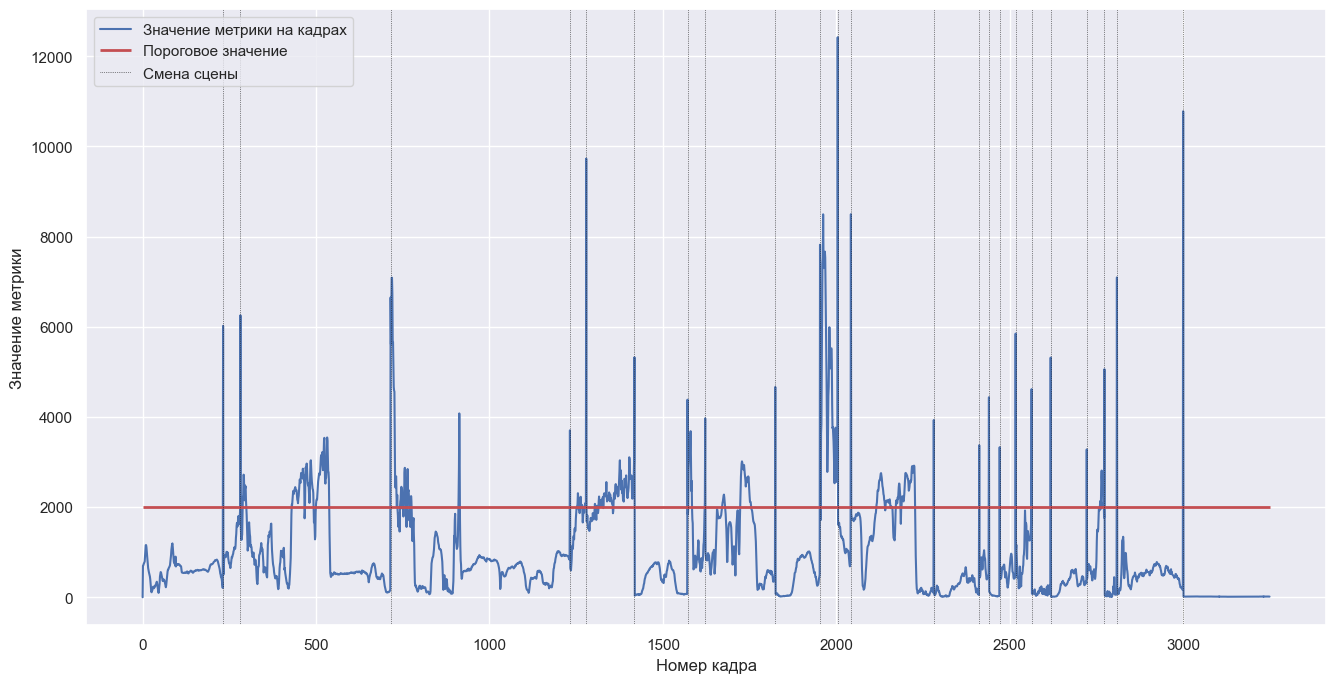

In [13]:
visualize_metric_values(metric_values_base, 2000, cuts_base)

**Как видим, очень плохо подобран порог, да и сам признак, похоже, сильно зашумлён. Попробуйте что-то своё!**

### Ваше решение

* В качестве решения вы должны прикрепить функцию ниже. Все пороги должны быть указаны внутри функции.  
Т.е. должен быть возможен вызов:  
`scene_changes, vis, metric_values = scene_change_detector(frames)`  
* Строку (# GRADED CELL: [function name]) менять **нельзя**. Она будет использоваться при проверке вашего решения.
* Ячейка должна содержать только **одну** функцию.

In [14]:
# GRADED CELL: scene_change_detector

def scene_change_detector(frames, threshold=None, with_vis=False):
    def compute_distance(feat1, feat2):
        color1, v1, struct1, is_bw1 = feat1
        color2, v2, struct2, is_bw2 = feat2

        if is_bw1 and is_bw2:
            intersect = np.sum(np.minimum(v1, v2))
        else:
            intersect = np.sum(np.minimum(color1, color2))

        dist_color = 1.0 - intersect

        std1 = np.std(struct1)
        std2 = np.std(struct2)

        if std1 < 1e-3 or std2 < 1e-3:
            dist_struct = dist_color
        else:
            s1_zero = struct1 - np.mean(struct1)
            s2_zero = struct2 - np.mean(struct2)

            num = np.sum(s1_zero * s2_zero)
            den = np.sqrt(np.sum(s1_zero**2) * np.sum(s2_zero**2)) + 1e-10

            zncc = num / den
            dist_struct = np.clip(1.0 - zncc, 0.0, 1.0)

        return 0.7 * dist_color + 0.3 * dist_struct

    scene_changes = []
    vis = [] if with_vis else None
    metric_values = []
    
    # Parameters
    DOWNSAMPLE_FACTOR = 2
    GRID_X, GRID_Y = 2, 2      
    
    HIST_BINS = 16
    
    WINDOW_SIZE = 5            
    MID_IDX = WINDOW_SIZE // 2 
    PEAK_RATIO = 3.0           
    MAX_NEIGHBOR_RATIO = 1.5   
    
    MIN_HARD_THRESH = 0.15     
    NOISE_FLOOR_WINDOW = 30    
    
    feature_buffer = []
    frame_buffer = []
    recent_metrics = []
    history_metrics = []       
    prev_frame = None
    
    for idx, frame in enumerate(frames):
        if DOWNSAMPLE_FACTOR > 1:
            h, w = frame.shape[:2]
            new_w, new_h = w // DOWNSAMPLE_FACTOR, h // DOWNSAMPLE_FACTOR
            frame_small = cv2.resize(frame, (new_w, new_h))
        else:
            frame_small = frame
            
        frame_small = cv2.GaussianBlur(frame_small, (5, 5), 0)
        
        hsv = cv2.cvtColor(frame_small, cv2.COLOR_BGR2HSV)
        
        mean_sat = np.mean(hsv[:, :, 1])
        is_bw_frame = (mean_sat < 8.0)
        
        h, w = hsv.shape[:2]
        block_h, block_w = h // GRID_Y, w // GRID_X
        
        color_hists = []
        v_hists = []
        
        for i in range(GRID_Y):
            for j in range(GRID_X):
                block = hsv[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
                pixels = block.shape[0] * block.shape[1]
                
                h_hist = np.histogram(block[:,:,0], bins=HIST_BINS, range=(0,180))[0] / pixels
                s_hist = np.histogram(block[:,:,1], bins=HIST_BINS, range=(0,256))[0] / pixels
                color_hists.extend([h_hist, s_hist])
                
                v_hist = np.histogram(block[:,:,2], bins=HIST_BINS, range=(0,256))[0] / pixels
                v_hists.extend([v_hist])
                
        color_feat = np.concatenate(color_hists).astype(np.float32)
        color_feat /= (GRID_Y * GRID_X * 2)  
        
        v_feat = np.concatenate(v_hists).astype(np.float32)
        v_feat /= (GRID_Y * GRID_X * 1)
        
        gray_tiny = cv2.resize(cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY), (16, 16)).astype(np.float32)
        

        current_feat = (color_feat, v_feat, gray_tiny, is_bw_frame)
        feature_buffer.append(current_feat)
        frame_buffer.append((idx, prev_frame, frame))
        

        if len(feature_buffer) > 1:
            dist = compute_distance(feature_buffer[-2], feature_buffer[-1])
            recent_metrics.append(dist)
            metric_values.append(dist)
            history_metrics.append(dist)
            
            if len(history_metrics) > NOISE_FLOOR_WINDOW:
                history_metrics.pop(0)
        else:
            recent_metrics.append(0.0)
            metric_values.append(0.0)
            

        if len(recent_metrics) == WINDOW_SIZE:
            mid_dist = recent_metrics[MID_IDX]
            
            neighbors = recent_metrics[:MID_IDX] + recent_metrics[MID_IDX+1:]
            local_avg = np.mean(neighbors)
            local_max = np.max(neighbors)
            

            is_spike = (mid_dist > (local_avg * PEAK_RATIO))
            

            is_isolated = (mid_dist > (local_max * MAX_NEIGHBOR_RATIO))
            

            dynamic_thresh = max(MIN_HARD_THRESH, np.median(history_metrics) * 3.0 if history_metrics else MIN_HARD_THRESH)
            is_high_enough = (mid_dist > (threshold if threshold else dynamic_thresh))
            

            feat_pre = feature_buffer[MID_IDX - 1] 
            feat_post = feature_buffer[MID_IDX + 1] 
            dist_jump = compute_distance(feat_pre, feat_post)
            
            is_not_flash = (dist_jump > mid_dist * 0.4)
            
            if is_spike and is_isolated and is_high_enough and is_not_flash:
                cut_idx, f_prev, f_curr = frame_buffer[MID_IDX]
                scene_changes.append(cut_idx)
                
                if with_vis and vis is not None and len(vis) < 100:
                    vis.append([f_prev, f_curr])
            

            recent_metrics.pop(0)
            feature_buffer.pop(0)
            frame_buffer.pop(0)
            
        if with_vis:
            prev_frame = frame
            
    return scene_changes, vis, metric_values

In [15]:
frames = read_video(os.path.join('train_dataset', 'video', '03.mp4'))
cuts = load_json_from_file(os.path.join('train_dataset', 'gt', '03.json'))['cut']
scene_changes, vis, metric_values = scene_change_detector(frames, with_vis=True)

#### Обратите внимание на скорость работы алгоритма! ####
Если вычислять признаки без циклов по пикселям, а пользоваться методами из numpy, то скорость будет не медленнее 7-8 кадров в секунду.
Например, вы можете использовать функцию `np.histogram` или `cv2.calcHist` для подсчёта гистограмм, а `cv2.Sobel` для применения оператора Собеля к кадру.

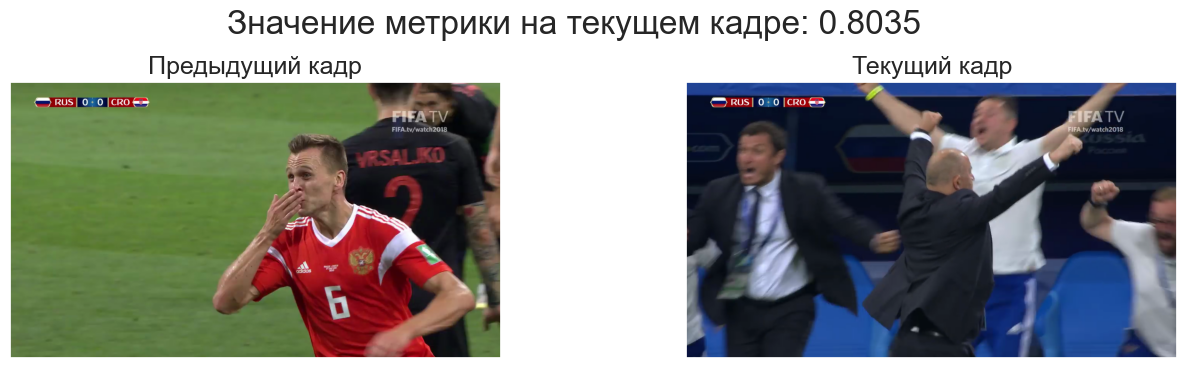

In [16]:
#Посмотрим на найденные смены сцен
idx = 1 
visualize_metric_error(vis[idx][0], vis[idx][1], metric_values[scene_changes[idx]])

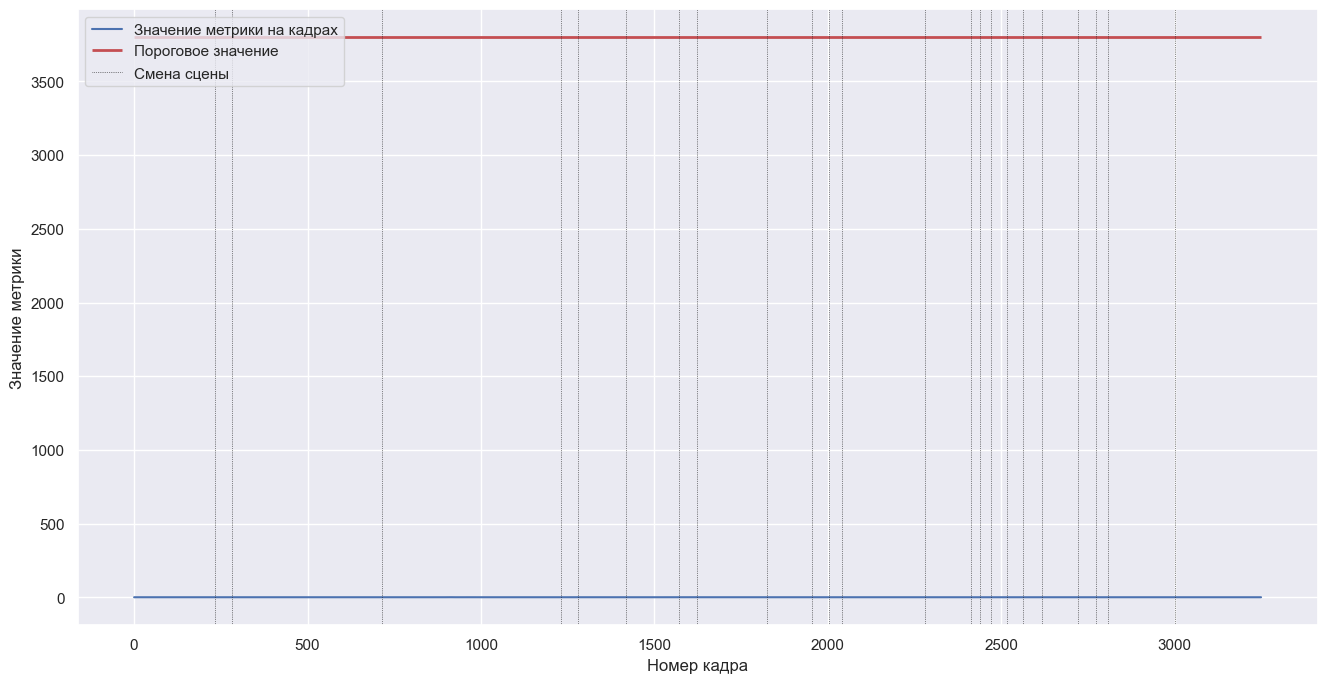

In [17]:
#Посмотрим на значения метрики
visualize_metric_values(metric_values, 3800, cuts)

### Подсчёт метрики F1-Score

Чтобы оценивать алгоритм и научиться сравнивать несколько алгоритмов, нужна метрика качества. В данной задаче для оценки качества алгоритма используется F1-Score. Преимущества использования этой метрики к текущей постановке задачи смены сцен были рассказаны на лекции, напишем только формулы:
$$precision = \frac{tp}{tp+fp}$$
$$recall = \frac{tp}{tp+fn}$$
$$F = 2 * \frac{precision * recall}{precision+recall}$$

На всякий случай опишем как именно происходит подсчёт метрики для видео

1) Сначала из выборки удаляются все кадры, которые по разметке либо являются сложными переходами между сценами, либо помечены как сложные для анализа и разметки (например, титры/обилие компьютерной графики и т.п)


2) Затем для оставшихся кадров уже подсчитывается F1_Score

In [18]:
#Эти пять клеток кода править не нужно
def calculate_matrix(true_scd, predicted_scd, scene_len, not_to_use_frames=set()):
    predicted_scd = set(predicted_scd)
    tp, fp, tn, fn = 0, 0, 0, 0
    scene_len = scene_len
    for scd in predicted_scd:
        if scd in true_scd:
            tp += 1
        elif scd not in not_to_use_frames:
            fp += 1
    for scd in true_scd:
        if scd not in predicted_scd:
            fn += 1
    tn = scene_len - len(not_to_use_frames) - tp - fp - fn
    return tp, fp, tn, fn

In [19]:
def calculate_precision(tp, fp, tn, fn):
    return tp / max(1, (tp + fp))

In [20]:
def calculate_recall(tp, fp, tn, fn):
    return tp / max(1, (tp + fn))

In [21]:
def f1_score(true_scd, predicted_scd, scene_len, not_to_use_frames=set()):
    tp, fp, tn, fn = calculate_matrix(true_scd, predicted_scd, scene_len, not_to_use_frames)
    precision_score = calculate_precision(tp, fp, tn, fn)
    recall_score = calculate_recall(tp, fp, tn, fn)
    if precision_score + recall_score == 0:
        return 0
    else:
        return 2 * precision_score * recall_score / (precision_score + recall_score)

In [22]:
def f1_score_matrix(tp, fp, tn, fn):
    precision_score = calculate_precision(tp, fp, tn, fn)
    recall_score = calculate_recall(tp, fp, tn, fn)
    if precision_score + recall_score == 0:
        return 0
    else:
        return 2 * precision_score * recall_score / (precision_score + recall_score)

### Тестируем разработанный метод сразу на нескольких видео 

Проверим, насколько хорошо работает разработанный метод. *Учтите, что итоговое тестирование будет производиться на аналогичном, но недоступном вам наборе видео, но все параметры алгоритмов должны быть указаны вами (иными словами - подобраны на тренировочном наборе).*

In [23]:
def run_scene_change_detector_all_video(scene_change_detector, dataset_path):
    """
    Evaluates cut detection while ignoring anything that falls into trash/dissolve/fade ranges.
    """
    video_dataset = load_json_from_file(os.path.join(dataset_path, 'info.json'))
    param_log = {
        '_mean_f1_score': []
    }
    
    for video_info in tqdm(video_dataset, leave=False):
        video_source = video_info['source']
        frames = read_video(os.path.join(dataset_path, video_source))
        video_len = video_info['len']
        true_scene_changes = load_json_from_file(os.path.join(dataset_path, video_info['scene_change']))
        
        # 1. Identify ALL ranges that should be ignored for cut evaluation
        ignore_ranges = []
        for transition_type in ['trash', 'fade', 'dissolve']:
            ranges = true_scene_changes.get(transition_type, [])
            ignore_ranges.extend(ranges)
            
        # Create a set for the metric functions to use internally
        not_use_frames = set()
        for start, end in ignore_ranges:
            # Standard inclusive range for frames
            not_use_frames.update(range(start, end + 1))
        
        # 2. Get raw predictions
        raw_predictions, _, _ = scene_change_detector(frames)
        
        # 3. Explicitly filter predictions locally as a fail-safe
        # If the prediction falls in an ignore zone, we act like it never happened.
        predicted_scene_changes = [
            p for p in raw_predictions 
            if p not in not_use_frames
        ]
        
        # 4. Calculate metrics
        # We pass not_use_frames to ensure the underlying math ignores GT cuts in those zones
        current_f1 = f1_score(
            true_scene_changes['cut'],
            predicted_scene_changes,
            video_len,
            not_use_frames
        )
        
        v_tp, v_fp, v_tn, v_fn = calculate_matrix(
            true_scene_changes['cut'],
            predicted_scene_changes,
            video_len,
            not_use_frames
        )
        
        param_log[f'f1_score_{video_source}'] = current_f1
        param_log[f'tp_{video_source}'] = v_tp
        param_log[f'fp_{video_source}'] = v_fp
        param_log[f'tn_{video_source}'] = v_tn
        param_log[f'fn_{video_source}'] = v_fn 
        param_log['_mean_f1_score'].append(current_f1)
        
    param_log['_mean_f1_score'] = np.mean(param_log['_mean_f1_score'])
    return param_log

In [24]:
video_dataset = 'train_dataset'

Данная функция поможет вам посмотреть, на каких видео и на сколько ошибается ваш метод. Прогнать метод на отдельном видео и детально посмотреть кадры вы могли выше.

Кроме того, с помощью этой функции вы можете подобрать оптимальные параметры для метода.

In [25]:
#Протестируем разработанный вами метод
run_scene_change_detector_all_video(scene_change_detector, video_dataset)

{'_mean_f1_score': 0.969119229402439,
 'f1_score_video/03.mp4': 1.0,
 'tp_video/03.mp4': 23,
 'fp_video/03.mp4': 0,
 'tn_video/03.mp4': 3172,
 'fn_video/03.mp4': 0,
 'f1_score_video/04.mp4': 0.967741935483871,
 'tp_video/04.mp4': 30,
 'fp_video/04.mp4': 2,
 'tn_video/04.mp4': 3356,
 'fn_video/04.mp4': 0,
 'f1_score_video/05.mp4': 0.9473684210526316,
 'tp_video/05.mp4': 18,
 'fp_video/05.mp4': 2,
 'tn_video/05.mp4': 5254,
 'fn_video/05.mp4': 0,
 'f1_score_video/07.mp4': 0.9705882352941176,
 'tp_video/07.mp4': 99,
 'fp_video/07.mp4': 3,
 'tn_video/07.mp4': 3216,
 'fn_video/07.mp4': 3,
 'f1_score_video/08.mp4': 1.0,
 'tp_video/08.mp4': 23,
 'fp_video/08.mp4': 0,
 'tn_video/08.mp4': 2587,
 'fn_video/08.mp4': 0,
 'f1_score_video/10.mp4': 0.9397590361445782,
 'tp_video/10.mp4': 39,
 'fp_video/10.mp4': 2,
 'tn_video/10.mp4': 2696,
 'fn_video/10.mp4': 3,
 'f1_score_video/14.mp4': 0.975609756097561,
 'tp_video/14.mp4': 40,
 'fp_video/14.mp4': 2,
 'tn_video/14.mp4': 1899,
 'fn_video/14.mp4': 0,


Когда вы смотрите на результат, обращайте внимание на **_mean_f1_score**  
Именно по этой метрике будет производится финальное оценивание.

## Бонусное задание: распознавание смен сцен типа "наложения"

На практике кроме катов часто встречаются смены сцен, где происходит "наложение" одной сцены на другую:

<img src="Dissolve.jpg">

### Ваше решение 

* В качестве решения вы должны прикрепить функцию ниже. Все пороги должны быть указаны внутри функции.  
Т.е. должен быть возможен вызов:  
`scene_changes, vis, metric_values = scene_change_detector_dissolve(frames)`  
* Строку (# GRADED CELL: [function name]) менять **нельзя**. Она будет использоваться при проверке вашего решения.
* Ячейка должна содержать только **одну** функцию.

In [26]:
# GRADED CELL: scene_change_detector_dissolve
def scene_change_detector_dissolve(frames_generator, with_vis=False):
    frames = [] 
    gray_frames = [] 
    
    while True:
        try:
            frame = next(frames_generator)
            
            if with_vis:
                frames.append(cv2.resize(frame, (256, 256)))
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            small = cv2.resize(gray, (32, 32)).astype(np.float32) / 255.0
            gray_frames.append(small)
            
        except StopIteration:
            break
            
    N = len(gray_frames)
    if N < 30:
        return [], [] if with_vis else None, []

    frame_diffs = [np.mean(np.abs(gray_frames[i] - gray_frames[i-1])) for i in range(1, N)]
    global_motion = np.mean(frame_diffs)
    
    is_high_action = global_motion > 0.035 
    
    motion_relax = 0.5 if is_high_action else 1.0 
    
    MIN_PIXEL_DIFF = 0.03
    BASE_RATIO_THRESH = 2.1 if is_high_action else 2.2
    
    HIST_MOTION_THRESH = 0.4 * motion_relax
    MAX_BLEND_ERROR_FOR_PAN_BYPASS = 0.025
    
    CONTRAST_INCREASE_THRESH = 1.1
    CONTRAST_DROP_THRESH = 0.95
    CONTRAST_PENALTY_WEIGHT = 0.5 * motion_relax
    

    metric_values = np.zeros(N)
    windows = [5, 10, 15, 20, 25] 
    
    for t in range(max(windows), N - max(windows)):
        best_ratio = 0.0
        
        for W in windows:
            img_prev = gray_frames[t - W]
            img_next = gray_frames[t + W]
            img_curr = gray_frames[t]
            
            diff = np.mean(np.abs(img_next - img_prev))
            if diff < MIN_PIXEL_DIFF: 
                continue
                
            blend = (img_prev + img_next) / 2.0
            error = np.mean(np.abs(img_curr - blend))
            
            ratio = diff / (error + 0.01)
            
            hist_prev, _ = np.histogram(img_prev, bins=16, range=(0.0, 1.0))
            hist_next, _ = np.histogram(img_next, bins=16, range=(0.0, 1.0))
            
            hist_prev = hist_prev / (32.0 * 32.0)
            hist_next = hist_next / (32.0 * 32.0)
            hist_diff = np.sum(np.abs(hist_prev - hist_next))
            
            hist_motion_ratio = hist_diff / (diff + 0.001)
            
            if hist_motion_ratio < HIST_MOTION_THRESH and error > MAX_BLEND_ERROR_FOR_PAN_BYPASS:
                ratio *= (hist_motion_ratio / HIST_MOTION_THRESH)
            std_prev = np.std(img_prev)
            std_next = np.std(img_next)
            std_curr = np.std(img_curr)
            
            std_mean = (std_prev + std_next) / 2.0
            
            if min(std_prev, std_next) > 0.05:
                std_ratio = std_curr / (std_mean + 0.001)
                
                if std_ratio > CONTRAST_INCREASE_THRESH:
                    ratio *= 0.2
                elif std_ratio > CONTRAST_DROP_THRESH:
                    penalty_range = CONTRAST_INCREASE_THRESH - CONTRAST_DROP_THRESH
                    violation_amount = (std_ratio - CONTRAST_DROP_THRESH) / penalty_range
                    penalty = 1.0 - (violation_amount * CONTRAST_PENALTY_WEIGHT)
                    ratio *= penalty
            
            if ratio > best_ratio:
                best_ratio = ratio
                
        metric_values[t] = best_ratio
        
    scene_changes = []
    vis = [] if with_vis else None
    
    candidate_frames = [i for i, val in enumerate(metric_values) if val > BASE_RATIO_THRESH]
    
    if candidate_frames:
        current_group = [candidate_frames[0]]
        for i in range(1, len(candidate_frames)):
            if candidate_frames[i] - current_group[-1] <= 30:
                current_group.append(candidate_frames[i])
            else:
                best_idx = max(current_group, key=lambda x: metric_values[x])
                scene_changes.append(best_idx)
                
                if with_vis and frames:
                    W_vis = 25
                    v_start = max(0, best_idx - W_vis)
                    v_end = min(N-1, best_idx + W_vis)
                    vis.append([frames[v_start], frames[v_end]])
                    
                current_group = [candidate_frames[i]]
                
        best_idx = max(current_group, key=lambda x: metric_values[x])
        scene_changes.append(best_idx)
        
        if with_vis and frames:
            W_vis = 25
            v_start = max(0, best_idx - W_vis)
            v_end = min(N-1, best_idx + W_vis)
            vis.append([frames[v_start], frames[v_end]])
            
    if len(scene_changes) == 0:
        best_idx = int(np.argmax(metric_values))
        if metric_values[best_idx] > 1.2: 
            scene_changes.append(best_idx)
            if with_vis and frames:
                W_vis = 25
                v_start = max(0, best_idx - W_vis)
                v_end = min(N-1, best_idx + W_vis)
                vis.append([frames[v_start], frames[v_end]])

    return scene_changes, vis, metric_values.tolist()


В качестве метрики качества используется видоизменённый f1-score:

Так как смена сцен не происходит за один кадр, попаданием считается попадание ответа смены сцен в отрезок, где происходит наложение.  
**Обратите внимание**, что несколько раз указывать одну смену сцен не нужно.

Попадание вне отрезков смен сцен путём наложения считается как false positive, не попадание в указанный отрезок - как false negative

In [27]:
#Эти три клетки кода править не нужно
def calculate_matrix_dissolve(true_scd, predicted_scd, scene_len):
    predicted_scd = set(predicted_scd)
    tp, fp, tn, fn = 0, 0, 0, 0
    scene_len = scene_len
    checked_dissolve_segments = set()
    total_scene_dissolve_len = np.sum([dissolve_segment[1] - dissolve_segment[0] + 1 for dissolve_segment in true_scd])
    for scd in predicted_scd:
        for dissolve_segment in true_scd:
            if scd in range(dissolve_segment[0], dissolve_segment[1] + 1):
                if tuple(dissolve_segment) not in checked_dissolve_segments:
                    tp += 1
                    checked_dissolve_segments.add(tuple(dissolve_segment))
                break
        else:
            fp += 1
    fn = len(true_scd) - len(checked_dissolve_segments)
    tn = scene_len - total_scene_dissolve_len + len(true_scd) - tp - fp - fn
    return tp, fp, tn, fn

In [28]:
def f1_score_dissolve(true_scd, predicted_scd, scene_len):
    tp, fp, tn, fn = calculate_matrix_dissolve(true_scd, predicted_scd, scene_len)
    precision_score = calculate_precision(tp, fp, tn, fn)
    recall_score = calculate_recall(tp, fp, tn, fn)
    if precision_score + recall_score == 0:
        return 0
    else:
        return 2 * precision_score * recall_score / (precision_score + recall_score)

In [29]:
# def run_scene_change_detector_all_video_dissolve(scene_change_detector, dataset_path):
#     video_dataset = load_json_from_file(os.path.join(dataset_path, 'info1.json'))
#     param_log = {
#         '_mean_f1_score': []
#     }
#     for video_info in tqdm(video_dataset, leave=False):
#         frames = read_video(os.path.join(dataset_path, video_info['source']))
#         video_len = video_info['len']
#         true_scene_changes = load_json_from_file(os.path.join(dataset_path, video_info['scene_change']))
        
#         predicted_scene_changes, _, _ = scene_change_detector(frames)
#         param_log['f1_score_{}'.format(video_info['source'])] = f1_score_dissolve(
#             true_scene_changes.get('dissolve', []),
#             predicted_scene_changes,
#             video_len
#         )
#         video_tp, video_fp, video_tn, video_fn = calculate_matrix_dissolve(
#             true_scene_changes.get('dissolve', []),
#             predicted_scene_changes,
#             video_len
#         )
#         param_log['tp_{}'.format(video_info['source'])] = video_tp
#         param_log['fp_{}'.format(video_info['source'])] = video_fp
#         param_log['tn_{}'.format(video_info['source'])] = video_tn
#         param_log['fn_{}'.format(video_info['source'])] = video_fn
#         param_log['_mean_f1_score'].append(param_log['f1_score_{}'.format(video_info['source'])])
#     param_log['_mean_f1_score'] = np.mean(param_log['_mean_f1_score'])
#     return param_log
def run_scene_change_detector_all_video_dissolve(scene_change_detector, dataset_path):
    video_dataset = load_json_from_file(os.path.join(dataset_path, 'info1.json'))
    param_log = {'_mean_f1_score': []}
    
    for video_info in tqdm(video_dataset, leave=False):
        video_path = os.path.join(dataset_path, video_info['source'])
        frames = read_video(video_path)
        video_len = video_info['len']
        gt = load_json_from_file(os.path.join(dataset_path, video_info['scene_change']))
        
        raw_preds, _, _ = scene_change_detector(frames)
        
        # Ignore if trash
        trash_ranges = gt.get('trash', [])
        predicted_scene_changes = [
            p for p in raw_preds 
            if not any(s <= p <= e for s, e in trash_ranges)
        ]
        
        v_tp, v_fp, v_tn, v_fn = calculate_matrix_dissolve(
            gt.get('dissolve', []),
            predicted_scene_changes,
            video_len
        )
        
        v_f1 = f1_score_dissolve(gt.get('dissolve', []), predicted_scene_changes, video_len)
        
        param_log[f'f1_score_{video_info["source"]}'] = v_f1
        param_log[f'tp_{video_info["source"]}'] = v_tp
        param_log[f'fp_{video_info["source"]}'] = v_fp
        param_log['_mean_f1_score'].append(v_f1)
        
    param_log['_mean_f1_score'] = np.mean(param_log['_mean_f1_score'])
    return param_log

In [ ]:
video_dataset_path = 'train_dataset'

In [33]:
#Протестируем разработанный вами метод
run_scene_change_detector_all_video_dissolve(scene_change_detector_dissolve, video_dataset_path)    


FileNotFoundError: [Errno 2] No such file or directory: 'public_tests/info1.json'

### Немного об оценивании задания

Оценивание задания будет производиться по следующей схеме:  

Пусть на скрытой выборке по F-метрике вы получили X, лучшее решение получило Y.

1. Базовая часть оценивется как $$20 * \left(\frac{\max(0, X_{base} - 0.5)}{Y_{base} - 0.5}\right)^2 + Bonus_{base}$$ Бонусные баллы $Bonus$ можно получить за оригинальные идеи в задаче или в её реализации
2. Дополнительное задание оценивается как $$5 * \frac{\max(0, X_{add} - 0.1)}{Y_{add} - 0.1} + Bonus_{add}$$Процесс получения бонусных баллов аналогичен получению бонусных баллов в базовой части

### Ваши ощущения ##

*До дедлайна пару часов и вы никак не можете улучшить текущее решение? Или наоборот, вы всё сделали очень быстро? Опишите кратко ваши ощущения от задания - сколько времени вы потратили на задание, сколько вы потратили на изучение питона и установку необходимых библиотек, как быстро вы придумывали новые идеи и как они давали прирост по метрике и в целом насколько это задание вам понравилось и что хотели бы изменить/добавить.*

<a id='second'></a>

## Задание 2. Scene change detector. Машинное обучение

**Внимание!**

В этом задании можно использовать все, что разрешалось в Задании №1, а также библиотеки:
* pandas
* sklearn

Большинство функций, использующихся в этом задании, реализованы выше.

### Бейзлайн

In [43]:
from sklearn.svm import SVC
import pandas as pd
import pickle

Обучим простой SVM классификатор над метрикой попиксельной разницы кадров на нескольких видео. Воспользуемся функцией из первого задания

In [44]:
def get_train_data(train_videos):
    X_train, y_train = np.array([]), np.array([])
    for video in train_videos:
        frames = read_video(os.path.join('train_dataset', 'video', f'{video}.mp4'))
        # baseline функция попиксельного сравнения кадров из прошлого задания
        # нам нужны не сами смены сцен, а только значения метрик
        _, _, metric_values = baseline_scene_change_detector(frames) 
        
        cuts = load_json_from_file(os.path.join('train_dataset', 'gt', f'{video}.json'))['cut']
        video_scenes = np.array([0 for i in range(len(metric_values))])
        video_scenes[cuts] += 1
        
        # добавляем в разметку текущее видео
        X_train = np.hstack((X_train, metric_values))
        y_train = np.hstack((y_train, video_scenes))
        
    return X_train, y_train 

In [45]:
train_videos = ['04', '05']

X_train, y_train = get_train_data(train_videos)

In [46]:
# создание модели
# подберите лучшие параметры для данной задачи
params = {"kernel": "rbf", "C": 1}
model = SVC(**params)
model.fit(X_train.reshape(-1, 1), y_train)

SVC(C=1)

 Сохраним модель в файле *model.pkl*

In [47]:
pickle.dump(model, open("model.pkl", "wb"))

Посмотрим как модель работает на тестовых видео

Обратите внимание на то, что внутри функции модель загружается из памяти из файла *model.pkl*

In [48]:
def baseline_scene_change_detection_ml(frames):
    # подготавливаем данные для видео
    _, _, metric_values = baseline_scene_change_detector(frames) 
    X_test = np.array(metric_values).reshape(-1, 1)
    
    # загружаем модель и делаем предсказания
    model = pickle.load(open("model.pkl", 'rb')) 
    predict_cuts = model.predict(X_test)
    
    return np.where(predict_cuts > 0)[0], [], metric_values

In [49]:
def run_scene_change_detector_ml_one_video(scene_change_detector, dataset_path, video_num):
    video_info = load_json_from_file(os.path.join(dataset_path, 'info.json'))[video_num]
    
    # Загружаем видео, его длину и смены сцен
    frames = read_video(os.path.join(dataset_path, video_info['source']))
    video_len = video_info['len']
    true_scene_changes = load_json_from_file(os.path.join(dataset_path, video_info['scene_change']))

    # Составляем список сцен, которые не будут тестироваться
    not_use_frames = set()
    for type_scene_change in ['trash', 'fade', 'dissolve']:
        for bad_scene_range in true_scene_changes.get(type_scene_change, []):
            not_use_frames.update(list(range(bad_scene_range[0], bad_scene_range[1] + 1)))

    predicted_scene_changes, _, _ = scene_change_detector(frames)

    return f1_score(
        true_scene_changes['cut'],
        predicted_scene_changes,
        video_len,
        not_use_frames
    )

Посчитаем F1 score для одного видео:

In [50]:
video_num = 3
run_scene_change_detector_ml_one_video(baseline_scene_change_detection_ml, 'train_dataset', video_num)

0.8317757009345794

### Ваше решение

Чтобы использовать свою обученную модель при отправке решения, необходимо сохранить ее через пакет pickle в файл model.pkl и отправить его вместе с jupyter ноутбуком.
Этот файл вы можете открывать и использовать прямо в функции вашего решения

* В качестве решения вы должны прикрепить функцию ниже. Все пороги должны быть указаны внутри функции.  
Т.е. должен быть возможен вызов:  
`scene_changes, vis, metric_values = scene_change_detector_dissolve(frames)`  
* Строку (# GRADED CELL: [function name]) менять **нельзя**. Она будет использоваться при проверке вашего решения.
* Ячейка должна содержать только **одну** функцию.

In [55]:
# GRADED CELL: scene_change_detector_ml

def scene_change_detector_ml(frames, threshold=None, with_vis=False):
    def compute_distance(feat1, feat2):
        color1, v1, struct1, is_bw1 = feat1
        color2, v2, struct2, is_bw2 = feat2

        if is_bw1 and is_bw2:
            intersect = np.sum(np.minimum(v1, v2))
        else:
            intersect = np.sum(np.minimum(color1, color2))

        dist_color = 1.0 - intersect

        std1 = np.std(struct1)
        std2 = np.std(struct2)

        if std1 < 1e-3 or std2 < 1e-3:
            dist_struct = dist_color
        else:
            s1_zero = struct1 - np.mean(struct1)
            s2_zero = struct2 - np.mean(struct2)

            num = np.sum(s1_zero * s2_zero)
            den = np.sqrt(np.sum(s1_zero**2) * np.sum(s2_zero**2)) + 1e-10

            zncc = num / den
            dist_struct = np.clip(1.0 - zncc, 0.0, 1.0)

        return 0.7 * dist_color + 0.3 * dist_struct
    DOWNSAMPLE_FACTOR = 24
    GRID_X, GRID_Y = 2, 2      
    HIST_BINS = 16
    
    PEAK_RATIO = 3.0           
    MAX_NEIGHBOR_RATIO = 1.5   
    MIN_HARD_THRESH = 0.15     
    
    features = []
    saved_frames = []
    
    for idx, frame in enumerate(frames):
        if with_vis:
            saved_frames.append(frame)
            
        if DOWNSAMPLE_FACTOR > 1:
            h, w = frame.shape[:2]
            new_w, new_h = w // DOWNSAMPLE_FACTOR, h // DOWNSAMPLE_FACTOR
            frame_small = cv2.resize(frame, (new_w, new_h))
        else:
            frame_small = frame
            
        frame_small = cv2.GaussianBlur(frame_small, (5, 5), 0)
        hsv = cv2.cvtColor(frame_small, cv2.COLOR_BGR2HSV)
        
        mean_sat = np.mean(hsv[:, :, 1])
        is_bw_frame = (mean_sat < 8.0)
        
        h, w = hsv.shape[:2]
        block_h, block_w = h // GRID_Y, w // GRID_X
        
        color_hists = []
        v_hists = []
        
        for i in range(GRID_Y):
            for j in range(GRID_X):
                block = hsv[i*block_h:(i+1)*block_h, j*block_w:(j+1)*block_w]
                pixels = block.shape[0] * block.shape[1]
                
                h_hist = np.histogram(block[:,:,0], bins=HIST_BINS, range=(0,180))[0] / pixels
                s_hist = np.histogram(block[:,:,1], bins=HIST_BINS, range=(0,256))[0] / pixels
                color_hists.extend([h_hist, s_hist])
                
                v_hist = np.histogram(block[:,:,2], bins=HIST_BINS, range=(0,256))[0] / pixels
                v_hists.extend([v_hist])
                
        color_feat = np.concatenate(color_hists).astype(np.float32)
        color_feat /= (GRID_Y * GRID_X * 2)  
        
        v_feat = np.concatenate(v_hists).astype(np.float32)
        v_feat /= (GRID_Y * GRID_X * 1)
        
        gray_tiny = cv2.resize(cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY), (16, 16)).astype(np.float32)
        
        features.append((color_feat, v_feat, gray_tiny, is_bw_frame))

    n = len(features)
    if n < 2:
        return [], [], []

    distances = np.zeros(n - 1)
    for i in range(n - 1):
        distances[i] = compute_distance(features[i], features[i+1])
        
    metric_values = distances.tolist()
    
    clean_distances = np.copy(distances)
    MAX_STROBE_LEN = 10 
    
    i = 0
    while i < n - 1:
        if clean_distances[i] > MIN_HARD_THRESH:
            for step in range(2, MAX_STROBE_LEN + 1):
                if i + step < n:
                    skip_dist = compute_distance(features[i], features[i+step])
                    
                    if skip_dist < min(MIN_HARD_THRESH, clean_distances[i] * 0.4):
                        for j in range(i, i + step):
                            clean_distances[j] = min(clean_distances[j], skip_dist)
                        i += step - 1 
                        break
        i += 1

    scene_changes = []
    vis = [] if with_vis else None
    
    for i in range(1, n - 2):
        val = clean_distances[i]
        
        hist_start = max(0, i - 30)
        local_history = clean_distances[hist_start:i]
        
        if len(local_history) > 0:
            noise_floor = np.median(local_history)
        else:
            noise_floor = MIN_HARD_THRESH
            
        dynamic_thresh = max(MIN_HARD_THRESH, noise_floor * 3.0)
        final_thresh = threshold if threshold else dynamic_thresh
        
        if val < final_thresh:
            continue
            
        start_idx = max(0, i - 5)
        end_idx = min(n - 1, i + 6)
        neighbors = np.concatenate((clean_distances[start_idx:i], clean_distances[i+1:end_idx]))
        
        local_avg = np.mean(neighbors) + 1e-5
        local_max = np.max(neighbors) + 1e-5
        
        if val > local_avg * PEAK_RATIO and val > local_max * MAX_NEIGHBOR_RATIO:
            cut_idx = i + 1
            scene_changes.append(cut_idx)
            
            if with_vis and len(vis) < 100:
                vis.append([saved_frames[cut_idx - 1], saved_frames[cut_idx]])
                
    return scene_changes, vis, metric_values

Проверим ваше решение на всех видео.

Не забывайте о том, что при итоговой оценке решений будет использоваться другой набор видео. Не переобучите модель!

In [56]:
video_dataset_path = 'train_dataset'

In [57]:
run_scene_change_detector_all_video(scene_change_detector_ml, video_dataset_path)

{'_mean_f1_score': 0.9764400047287328,
 'f1_score_video/03.mp4': 1.0,
 'tp_video/03.mp4': 23,
 'fp_video/03.mp4': 0,
 'tn_video/03.mp4': 3172,
 'fn_video/03.mp4': 0,
 'f1_score_video/04.mp4': 1.0,
 'tp_video/04.mp4': 30,
 'fp_video/04.mp4': 0,
 'tn_video/04.mp4': 3358,
 'fn_video/04.mp4': 0,
 'f1_score_video/05.mp4': 0.9473684210526316,
 'tp_video/05.mp4': 18,
 'fp_video/05.mp4': 2,
 'tn_video/05.mp4': 5254,
 'fn_video/05.mp4': 0,
 'f1_score_video/07.mp4': 0.9753694581280787,
 'tp_video/07.mp4': 99,
 'fp_video/07.mp4': 2,
 'tn_video/07.mp4': 3217,
 'fn_video/07.mp4': 3,
 'f1_score_video/08.mp4': 1.0,
 'tp_video/08.mp4': 23,
 'fp_video/08.mp4': 0,
 'tn_video/08.mp4': 2587,
 'fn_video/08.mp4': 0,
 'f1_score_video/10.mp4': 0.9761904761904762,
 'tp_video/10.mp4': 41,
 'fp_video/10.mp4': 1,
 'tn_video/10.mp4': 2697,
 'fn_video/10.mp4': 1,
 'f1_score_video/14.mp4': 0.9876543209876543,
 'tp_video/14.mp4': 40,
 'fp_video/14.mp4': 1,
 'tn_video/14.mp4': 1900,
 'fn_video/14.mp4': 0,
 'f1_score_v

**Советы**

* Используйте кросс-валидацию
* Подумайте как лучше разделять видео на тренировочную и тестовые выборки
* Подбирайте параметры модели (в библиотеке sklearn есть метод GridSearchCV для автоматического подбора параметров)
* Пробуйте разные методы машинного обучения (из sklearn)

## Бонусное задание: детектор смен сцен типа наложение

Аналогично детектору из задания №1 за исключением того, что можно (и нужно) использовать машинное обучение:)

In [ ]:
# GRADED CELL: scene_change_detector_dissolve_ml
def scene_change_detector_dissolve_ml(frames, threshold=None, with_vis=False):
    gray_frames = [] 
    
    for frame in frames:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        small = cv2.resize(gray, (60, 60)).astype(np.float32) / 255.0
        gray_frames.append(small)
            
    N = len(gray_frames)
    if N < 30:
        return [], [] if with_vis else None, []

    frame_diffs = [np.mean(np.abs(gray_frames[i] - gray_frames[i-1])) for i in range(1, N)]
    global_motion = np.mean(frame_diffs)
    
    is_high_action = global_motion > 0.05
    
    motion_relax = 0.5 if is_high_action else 1.0 
    
    MIN_PIXEL_DIFF = 0.1
    BASE_RATIO_THRESH = 2.1 if is_high_action else 2.2
    
    HIST_MOTION_THRESH = 0.4 * motion_relax
    MAX_BLEND_ERROR_FOR_PAN_BYPASS = 0.025
    
    CONTRAST_INCREASE_THRESH = 1.1
    CONTRAST_DROP_THRESH = 0.75
    CONTRAST_PENALTY_WEIGHT = 0.5 * motion_relax
    

    metric_values = np.zeros(N)
    windows = [5, 10, 15, 20, 25] 
    
    for t in range(max(windows), N - max(windows)):
        best_ratio = 0.0
        
        for W in windows:
            img_prev = gray_frames[t - W]
            img_next = gray_frames[t + W]
            img_curr = gray_frames[t]
            
            diff = np.mean(np.abs(img_next - img_prev))
            if diff < MIN_PIXEL_DIFF: 
                continue
                
            blend = (img_prev + img_next) / 2.0
            error = np.mean(np.abs(img_curr - blend))
            
            ratio = diff / (error + 0.01)
            
            hist_prev, _ = np.histogram(img_prev, bins=16, range=(0.0, 1.0))
            hist_next, _ = np.histogram(img_next, bins=16, range=(0.0, 1.0))
            
            hist_prev = hist_prev / (32.0 * 32.0)
            hist_next = hist_next / (32.0 * 32.0)
            hist_diff = np.sum(np.abs(hist_prev - hist_next))
            
            hist_motion_ratio = hist_diff / (diff + 0.001)
            
            if hist_motion_ratio < HIST_MOTION_THRESH and error > MAX_BLEND_ERROR_FOR_PAN_BYPASS:
                ratio *= (hist_motion_ratio / HIST_MOTION_THRESH)
            std_prev = np.std(img_prev)
            std_next = np.std(img_next)
            std_curr = np.std(img_curr)
            
            std_mean = (std_prev + std_next) / 2.0
            
            if min(std_prev, std_next) > 0.05:
                std_ratio = std_curr / (std_mean + 0.001)
                
                if std_ratio > CONTRAST_INCREASE_THRESH:
                    ratio *= 0.2
                elif std_ratio > CONTRAST_DROP_THRESH:
                    penalty_range = CONTRAST_INCREASE_THRESH - CONTRAST_DROP_THRESH
                    violation_amount = (std_ratio - CONTRAST_DROP_THRESH) / penalty_range
                    penalty = 1.0 - (violation_amount * CONTRAST_PENALTY_WEIGHT)
                    ratio *= penalty
            
            if ratio > best_ratio:
                best_ratio = ratio
                
        metric_values[t] = best_ratio
        
    scene_changes = []
    vis = [] if with_vis else None
    
    candidate_frames = [i for i, val in enumerate(metric_values) if val > BASE_RATIO_THRESH]
    
    if candidate_frames:
        current_group = [candidate_frames[0]]
        for i in range(1, len(candidate_frames)):
            if candidate_frames[i] - current_group[-1] <= 35:
                current_group.append(candidate_frames[i])
            else:
                best_idx = max(current_group, key=lambda x: metric_values[x])
                scene_changes.append(best_idx)
                
                if with_vis:
                    W_vis = 25
                    v_start = max(0, best_idx - W_vis)
                    v_end = min(N-1, best_idx + W_vis)
                    vis.append([frames[v_start], frames[v_end]])
                    
                current_group = [candidate_frames[i]]
                
        best_idx = max(current_group, key=lambda x: metric_values[x])
        scene_changes.append(best_idx)
        
        if with_vis:
            W_vis = 25
            v_start = max(0, best_idx - W_vis)
            v_end = min(N-1, best_idx + W_vis)
            vis.append([frames[v_start], frames[v_end]])
            
    if len(scene_changes) == 0:
        best_idx = int(np.argmax(metric_values))
        if metric_values[best_idx] > 1.2: 
            scene_changes.append(best_idx)
            if with_vis:
                W_vis = 25
                v_start = max(0, best_idx - W_vis)
                v_end = min(N-1, best_idx + W_vis)
                vis.append([frames[v_start], frames[v_end]])

    return scene_changes, vis, metric_values.tolist()

In [ ]:
video_dataset_path = 'train_dataset'
#Протестируем разработанный вами метод
run_scene_change_detector_all_video_dissolve(scene_change_detector_dissolve, video_dataset_path)


### Ваши ощущения ##

*Как и в первой части интересно узнать какие моменты показались простыми, а какие сложными. Много ли времени ушло на изучение sklearn и методов машинного обучения. Дало ли машинное обучение сразу прирост по сравнению с эврестической частью? Как вы контролировали переобучение?*

In [37]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import base64
import json
from IPython.display import display, HTML

def save_and_show_frame(video_path, frame_number, output_dir="extracted_frames", label="frame", show_in_notebook=True):
    """
    Extracts a specific frame, saves it, and optionally displays it in the notebook.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    ret, frame = cap.read()
    if ret:
        file_name = f"{label}_{frame_number}.jpg"
        save_path = os.path.join(output_dir, file_name)
        cv2.imwrite(save_path, frame)
        
        if show_in_notebook:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10, 6))
            plt.imshow(frame_rgb)
            plt.title(f"{label} - Frame {frame_number}")
            plt.axis('off')
            plt.show()
    else:
        print(f"Error: Could not read frame {frame_number} from {video_path}")
    
    cap.release()

def create_interactive_player(video_path, start_frame, end_frame):
    """
    Creates an interactive HTML player in the notebook.
    Use LEFT/RIGHT arrow keys to navigate frames.
    """
    cap = cv2.VideoCapture(video_path)
    frames_base64 = []
    
    print(f"Buffering {end_frame - start_frame + 1} frames for the player... ☕️")
    
    for f_idx in range(start_frame, end_frame + 1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
        ret, frame = cap.read()
        if ret:
            small = cv2.resize(frame, (640, 360))
            _, buffer = cv2.imencode('.jpg', small)
            b64 = base64.b64encode(buffer).decode('utf-8')
            frames_base64.append((f_idx, b64))
    cap.release()

    if not frames_base64:
        print("No frames found. Check your video path.")
        return

    html_template = f"""
    <div id="player_container" style="border: 2px solid #333; padding: 10px; border-radius: 8px; width: 660px; background: #000;">
        <div style="color: white; margin-bottom: 5px; font-family: sans-serif;">
            Frame: <span id="frame_num_display">{{start_frame}}</span> / {{end_frame}} 
            <span style="float: right; font-size: 0.8em; color: #888;">Use ← → keys</span>
        </div>
        <img id="player_img" src="data:image/jpeg;base64,{{frames_base64[0][1]}}" style="width: 640px; height: 360px;">
    </div>

    <script>
    (function() {{
        const frames = {[{'idx': f[0], 'src': f[1]} for f in frames_base64]};
        let currentIdx = 0;
        const img = document.getElementById('player_img');
        const display = document.getElementById('frame_num_display');

        function updateFrame(newIdx) {{
            if (newIdx >= 0 && newIdx < frames.length) {{
                currentIdx = newIdx;
                img.src = "data:image/jpeg;base64," + frames[currentIdx].src;
                display.innerText = frames[currentIdx].idx;
            }}
        }}

        const handleKey = function(event) {{
            if (event.key === "ArrowRight") {{
                updateFrame(currentIdx + 1);
                event.preventDefault();
            }} else if (event.key === "ArrowLeft") {{
                updateFrame(currentIdx - 1);
                event.preventDefault();
            }}
        }};

        document.removeEventListener('keydown', handleKey);
        document.addEventListener('keydown', handleKey);
    }})();
    </script>
    """
    display(HTML(html_template))

def evaluate_bonus_task_1(video_path, detector_func, gt_json_path):
    """
    Evaluates the dissolve detector with strict 'one-hit' rules.
    If multiple predictions land in one GT range, subsequent hits are FPs.
    """
    with open(gt_json_path, 'r') as f:
        gt_data = json.load(f)
    
    gt_ranges = gt_data.get("dissolve", [])
    
    def frames_gen(path):
        cap = cv2.VideoCapture(path)
        while True:
            ret, frame = cap.read()
            if not ret: break
            yield frame
        cap.release()

    video_name = os.path.basename(video_path)
    print(f"Running detector on {video_name}... 🕵️‍♀️")
    predicted_frames, _, _ = detector_func(frames_gen(video_path))
    
    cap = cv2.VideoCapture(video_path)
    total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    tp, fp, fn = 0, 0, 0
    fp_frames = []
    fn_frames = []
    double_tap_frames = []
    matched_gt_indices = set()
    
    for pred in predicted_frames:
        hit = False
        for i, (start, end) in enumerate(gt_ranges):
            if start <= pred <= end:
                if i not in matched_gt_indices:
                    tp += 1
                    matched_gt_indices.add(i)
                else:
                    # Double tap detected
                    fp += 1
                    double_tap_frames.append(pred)
                    save_and_show_frame(video_path, pred, "debug/double_taps", "DT", show_in_notebook=False)
                hit = True
                break
        
        if not hit:
            fp += 1
            fp_frames.append(pred)
            save_and_show_frame(video_path, pred, "debug/false_positives", "FP", show_in_notebook=False)

    for i, (start, end) in enumerate(gt_ranges):
        if i not in matched_gt_indices:
            fn += 1
            mid = (start + end) // 2
            fn_frames.append(mid)
            save_and_show_frame(video_path, mid, "debug/false_negatives", "FN", show_in_notebook=False)

    tn = total_f - (tp + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    if len(gt_ranges) == 0:
        f1 = 1.0 if fp == 0 else 0.0

    print(f"\n--- Bonus Task 1: {video_name} ---")
    print(f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
    print(f"Hallucination FPs: {fp_frames}")
    print(f"Double-tap FPs: {double_tap_frames}")
    print(f"Missed Midpoints (FN): {fn_frames}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    
    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn, 
        "f1": f1, "fp_frames": fp_frames, "fn_frames": fn_frames,
        "double_taps": double_tap_frames
    }

def analyze_and_debug_results(video_path, predicted_frames, ground_truth_frames, window=15, total_frames=None):
    """
    Original simple debug suite for frame-to-frame matching.
    """
    os.makedirs("debug/false_positives", exist_ok=True)
    os.makedirs("debug/false_negatives", exist_ok=True)
    
    tp, fp, fn = 0, 0, 0
    matched_gt = set()
    
    for pred in predicted_frames:
        found = False
        for gt in ground_truth_frames:
            if abs(pred - gt) <= window:
                tp += 1
                matched_gt.add(gt)
                found = True
                break
        if not found:
            fp += 1
            save_and_show_frame(video_path, pred, "debug/false_positives", "FP", show_in_notebook=False)

    for gt in ground_truth_frames:
        if gt not in matched_gt:
            fn += 1
            save_and_show_frame(video_path, gt, "debug/false_negatives", "FN", show_in_notebook=False)

    tn = 0
    if total_frames:
        tn = total_frames - (tp + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n--- Results for {os.path.basename(video_path)} ---")
    print(f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn if total_frames else 'N/A'}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    
    if tp == 0 and len(ground_truth_frames) == 0:
        if fp == 0:
            print("Perfect TN performance on a zero-dissolve video! 🌟")
            f1 = 1.0 
        else:
            print(f"Flopped on zero-dissolve video: {fp} Hallucinations. 👺")
            
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn, "f1": f1}

VIDEO_PATH = "train_dataset/video/05.mp4"
GT_JSON = "train_dataset/gt/05.json"

if os.path.exists(VIDEO_PATH) and os.path.exists(GT_JSON):
    evaluate_bonus_task_1(VIDEO_PATH, scene_change_detector_dissolve, GT_JSON)
else:
    print("Check your paths for VIDEO_PATH and GT_JSON. 💅")



Running detector on 05.mp4... 🕵️‍♀️

--- Bonus Task 1: 05.mp4 ---
TP: 5 | FP: 6 | FN: 0 | TN: 5651
Hallucination FPs: [818, 4327, 5150, 5237, 5341, 5476]
Double-tap FPs: []
Missed Midpoints (FN): []
Precision: 0.4545 | Recall: 1.0000 | F1: 0.6250


In [38]:
import cv2
import os
import json

def evaluate_cut_performance(video_path, detector_func, gt_json_path):
    """
    Strict evaluation for cut detection. 
    A prediction is a TP only if it exactly matches a frame in the GT 'cut' list.
    Ignores predictions in 'trash' and 'dissolve' zones.
    """
    if not os.path.exists(gt_json_path):
        print(f"Error: JSON not found at {gt_json_path}")
        return None

    with open(gt_json_path, 'r') as f:
        gt_data = json.load(f)
    
    # Exact frames for cuts
    gt_cuts = set(gt_data.get("cut", []))
    
    # Zones to ignore (don't count as FP for the cut task)
    trash_ranges = gt_data.get("trash", [])
    dissolve_ranges = gt_data.get("dissolve", [])
    
    ignore_zones = trash_ranges + dissolve_ranges

    def frames_gen(path):
        cap = cv2.VideoCapture(path)
        while True:
            ret, frame = cap.read()
            if not ret: break
            yield frame
        cap.release()

    video_name = os.path.basename(video_path)
    print(f"Running cut detector on {video_name}... 🕵️‍♀️")
    
    # Run your heuristic
    predicted_frames, _, _ = detector_func(frames_gen(video_path))
    
    tp = 0
    fp = 0
    matched_cuts = set()
    fp_frames = []

    for pred in predicted_frames:
        # 1. Exact match check
        if pred in gt_cuts:
            if pred not in matched_cuts:
                tp += 1
                matched_cuts.add(pred)
            continue
            
        # 2. Check if it should be ignored (Trash/Dissolve)
        is_ignored = any(start <= pred <= end for start, end in ignore_zones)
        if is_ignored:
            continue
            
        # 3. Otherwise, it's a hallucination
        fp += 1
        fp_frames.append(pred)

    # 4. Calculate missed cuts (FN)
    fn_frames = sorted(list(gt_cuts - matched_cuts))
    fn = len(fn_frames)

    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n--- Cut Results: {video_name} ---")
    print(f"TP: {tp} | FP: {fp} | FN: {fn}")
    print(f"F1 Score: {f1:.4f}")
    if fp_frames:
        print(f"False Positive Frames: {fp_frames}")
    if fn_frames:
        print(f"Missed Cut Frames (FN): {fn_frames}")
        
    return {"tp": tp, "fp": fp, "fn": fn, "f1": f1}

# Usage:
evaluate_cut_performance("public_tests/03_test_file_input/video/07.mp4", scene_change_detector, "public_tests/03_test_file_input/gt/07.json")

Running cut detector on 07.mp4... 🕵️‍♀️

--- Cut Results: 07.mp4 ---
TP: 99 | FP: 3 | FN: 3
F1 Score: 0.9706
False Positive Frames: [11, 2625, 3312]
Missed Cut Frames (FN): [273, 1250, 1796]


{'tp': 99, 'fp': 3, 'fn': 3, 'f1': 0.9705882352941176}

In [ ]:
create_interactive_player(VIDEO_PATH,4063,6000)
# save_and_show_frame(VIDEO_PATH,5376)